In this reading assignment, you will learn about the concepts of Standardization and minmax technique for normalising data on a neural network.

## Prerequisites:
To start with Standardisation and minmax, you must have knowledge about:
- Concepts of Mean, Variance
- Concepts of minimum and maximum of a number

## Learning Objectives:
By the end of the lesson, all learners will be able to (minimum expected from everyone) :
- Recollect the importance of scaling a value between certain range
- Explain standardisation and min-max technique used to squeeze value between certain range
-Implement standardisation and min-max techniques
-Check the performance on the time of convergence of the neural network


## Standardization Normalisation
<center>
<figure>


<p>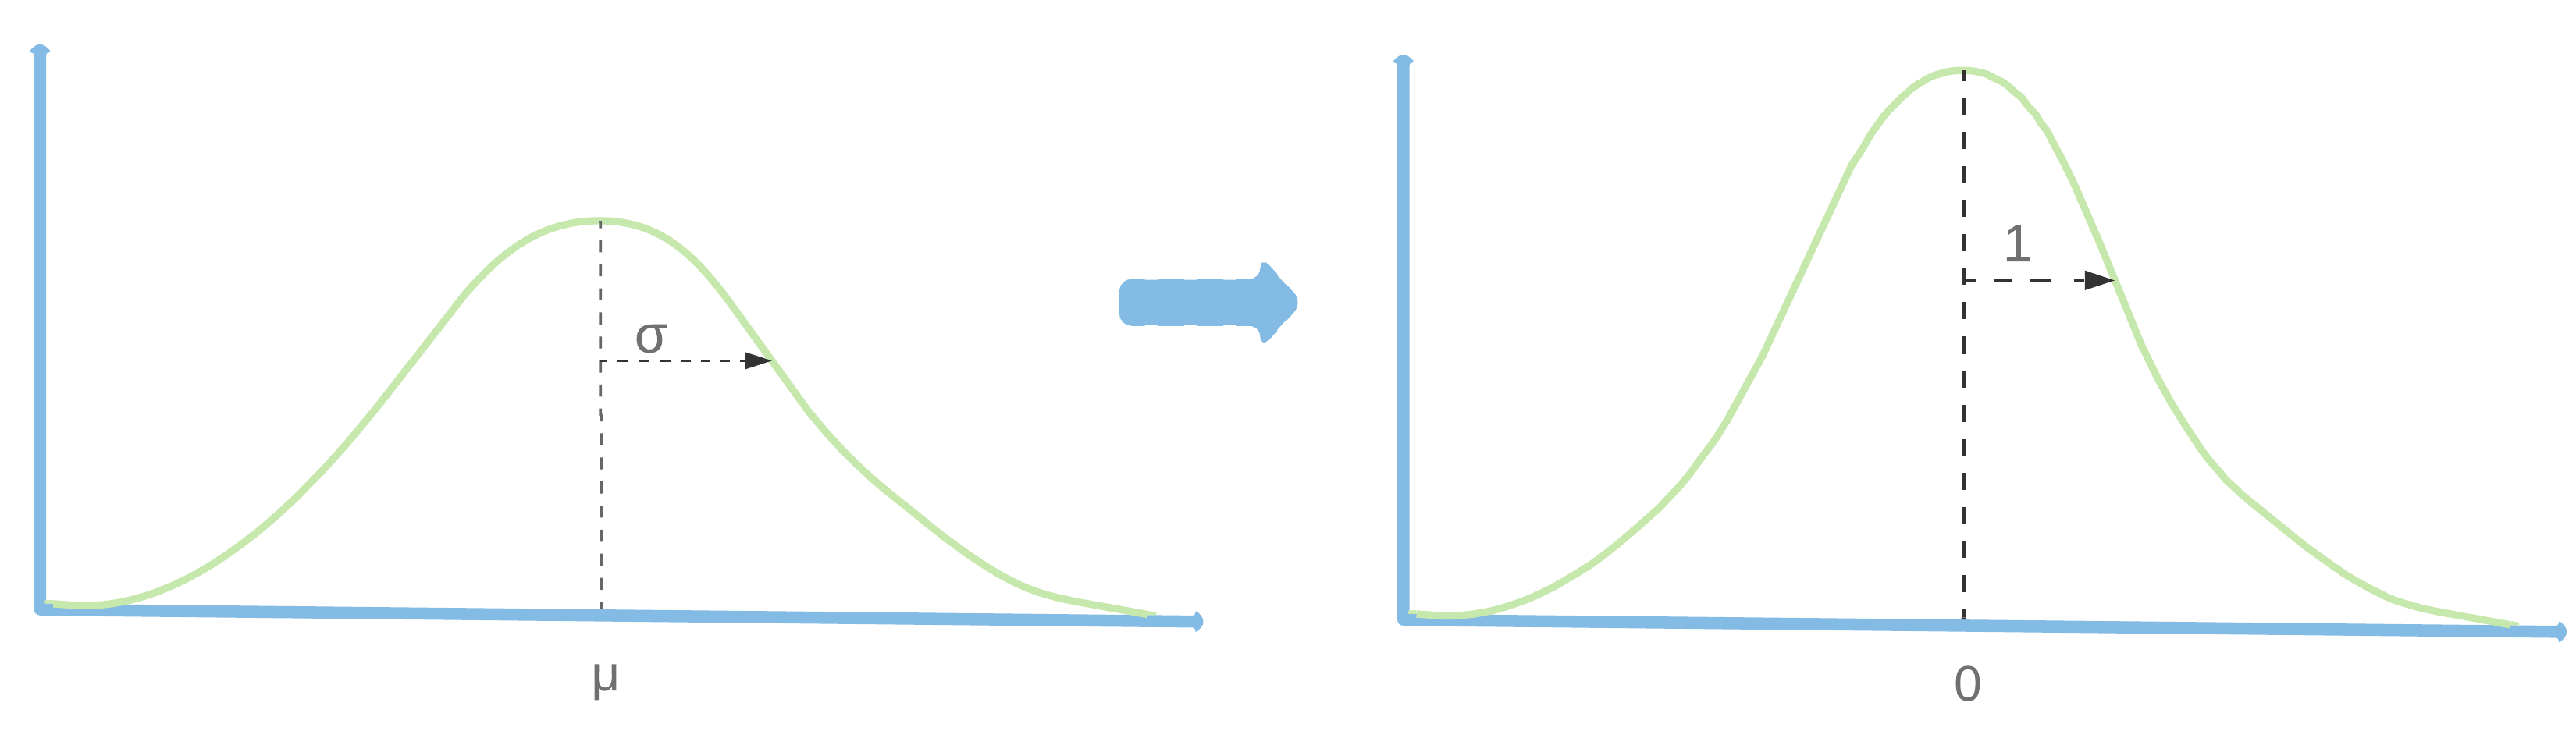</p>
<figcaption align="center">Figure 1: Standardization</figcaption>
</figure>
</center>
Standardization is a technique of data normalization in which datasets are transformed such that the mean is equal to zero and the standard deviation is equal to 1. It is a non-linear transformation. A dataset with a value less than mean is transformed to a negative value, with a value equal to mean is transformed to zero value and with a value greater than mean is transformed to a positive value. The degree of positivity and negativity depends on the standard deviation of the original data.

Standardization  is defined as
$$x_{scaled}=\frac{x-\mu}{\sigma}$$
where $\mu$ and $\sigma$ is standard deviation of data.
$$\mu=\frac{1}{N}\sum x_{i}$$
$$\sigma^2=\frac{\sum(x_i-\mu)^2}{N}$$

The question may arise when to use standardization. Consider a case of image processing where we are training a model based on images captured from DSLR and now testing on an image captured from a smartphone. Of course, the distribution of image data from different sources is different. The test result will not be satisfactory. So the image data must be normalized to have the same distribution. Different other distribution are also possible, but normal distribution ( $\mu=0$ and $\sigma=1$) is widely used.

The main advantage of using standardization (also called Z-score normalization) is that it is less sensitive to **outliers**.




## Min-Max Normalisation

It is one of the most common methods of normalization where each value is transformed to the range between 0 and 1 such that the minimum value of feature corresponds to 0 and the maximum value corresponds to 1.
$$ x_{scaled}=\frac{x-x_{min}}{x_{max}-x_{min}}$$
where,

$ x_{scaled}$ is  transformed data.

$x_{min}$ is the minimum value in the dataset.

$x_{max}$ is the maximum value in the dataset.


This normalization is a linear transformation.
<center>
<figure>


<p>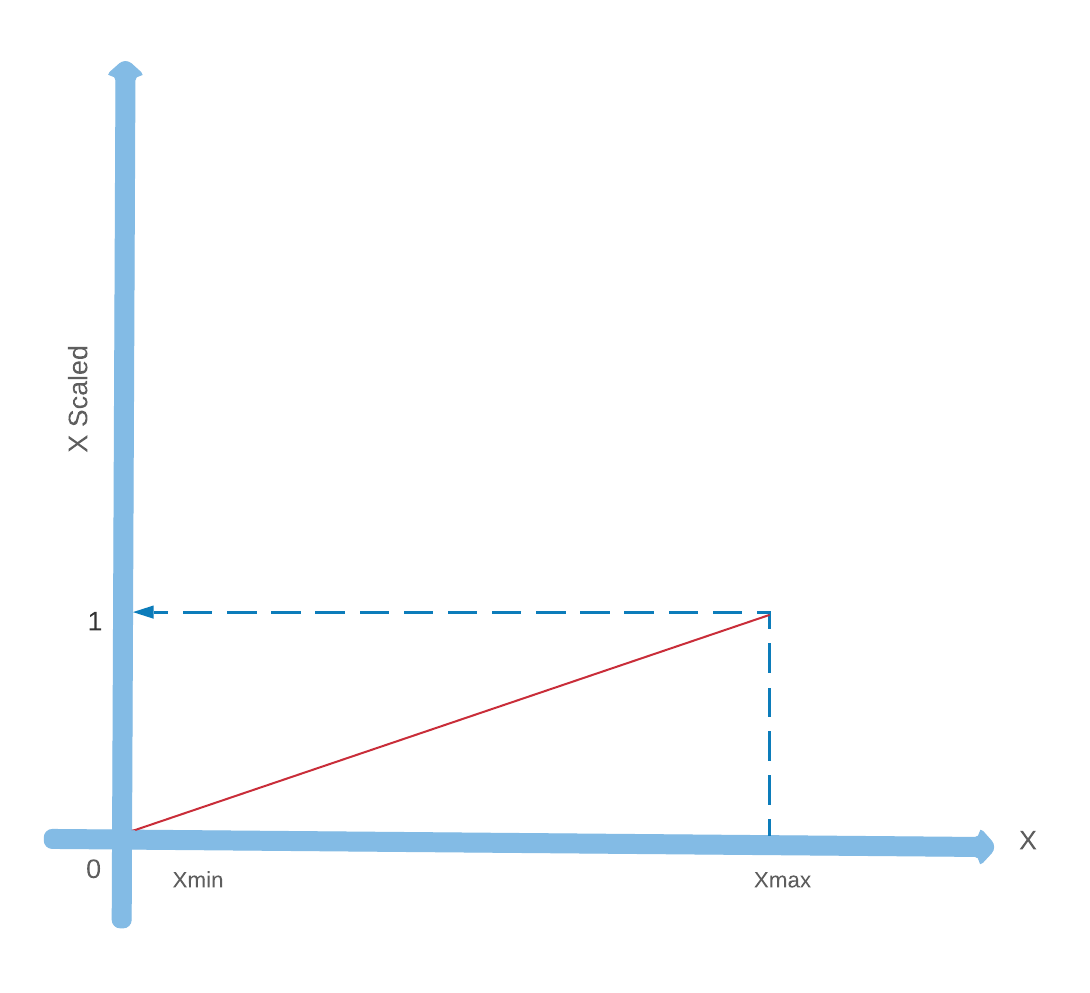</p>
<figcaption align="center">Figure 2: Min Max Normalization</figcaption>
</figure>
</center>

**Advantage:**

The advantage of min-max normalisation is that the computation time for scaling the values if comparatively less. It works well for data without outliers.

**Disadvantage:**

The main disadvantage of min-max normalization is that it is sensitive to outliers.
For example, in a list of 40 datasets if 39 datasets are less than or equal to 20 and one of them is 80, then the output of min-max normalization doesn't produce a desirable result. This drawback of min-max normalization is illustrated in the implementation part.







## Implementation of Standardization Normalization


In [ ]:
##import library
import numpy as np
import math as mth
import matplotlib.pyplot as plt

In [ ]:
# No. of samples data to normalize
N=50

# Select values between 0 and 10
x=np.random.randint(0,10,N-1)
x=list(x)

# 15 can work as a outlier so appending it
x.append(15)
print("X=",x)

print("\n")

# 50 random values between [0,1) then multiplied by 5
# Now our maximum value of y is ~= 5 when random generated value is 0.9999999999*5
y=np.random.rand(50)*5
print("y=",y)

X= [2, 7, 4, 7, 8, 8, 1, 5, 9, 8, 0, 4, 2, 9, 0, 5, 3, 8, 9, 9, 8, 5, 2, 9, 4, 9, 8, 0, 5, 8, 4, 3, 6, 9, 0, 4, 4, 0, 8, 6, 5, 6, 3, 7, 4, 4, 9, 3, 5, 15]


y= [0.04835262 1.11937016 3.06055763 0.13277875 3.56883179 0.4377211
 0.74540816 0.52494654 4.52813366 1.18392097 3.24861635 0.45097827
 4.46623351 1.51301383 2.24160701 3.94520415 2.11986376 0.76158327
 3.67107087 3.10399654 0.08901446 1.81533279 2.0976137  1.47034741
 3.35693522 2.91061275 0.6032083  3.35800015 3.95297869 2.38555565
 0.55127577 4.9367714  0.50309071 0.30337772 0.06470133 1.37739724
 2.28660154 3.20123859 1.97187801 2.70020559 1.15242647 3.05154831
 3.74396368 0.53321235 4.84331253 1.03319493 2.76084346 3.54836601
 2.02259407 0.81958219]


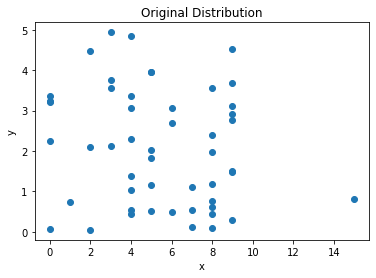

In [ ]:
#Plot of data
plt.scatter(x,y)
plt.title("Original Distribution")
plt.xlabel('x')
plt.ylabel('y')

plt.show()

In [ ]:
#Perform standarization
#compute mean
sum_x=sum(x)
sum_y=sum(y)
len_x=len(x)
len_y=len(y)
mean_x=sum_x/len_x
mean_y=sum_y/len_y


##compute std of x
var_x=0
for i in x:
  var_x+=(i-mean_x)**2
var_x=var_x/len_x
std_x=mth.sqrt(var_x)

#Compute std of y
var_y=0
for i in y:
  var_y+=(i-mean_y)**2
var_y=var_y/len_y
std_y=mth.sqrt(var_y)
x_scaled=[(a-mean_x)/std_x for a in x]
y_scaled=[(a-mean_y)/std_y for a in y]

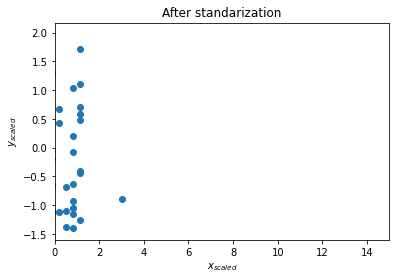

In [ ]:
#Plot of standarized data
plt.scatter(x_scaled,y_scaled)
plt.title("After standarization")
plt.xlabel('$x_{scaled}$')
plt.ylabel('$y_{scaled}$')
plt.xlim((0,15))
plt.show()

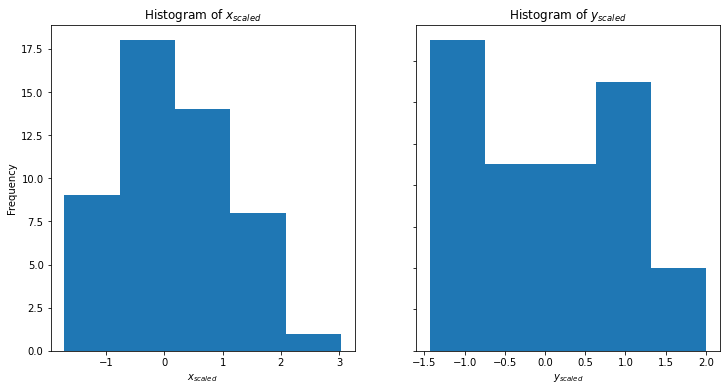

In [ ]:

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,6))

ax1.hist(x_scaled, bins=5)
ax1.set_title("Histogram of $x_{scaled}$")
ax1.set(xlabel='$x_{scaled}$',ylabel='Frequency')
ax1.label_outer()
ax2.hist(y_scaled, bins =5)
ax2.set_title("Histogram of $y_{scaled}$")
ax2.set(xlabel='$y_{scaled}$',ylabel='Frequency')
ax2.label_outer()

We cannot guarentee transformed data to lie between 0 and 1.






##Implementation Min Max Normalization


In [ ]:
##import library
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# initializing 50 random numbers between 0 and 10
N=50
x=np.random.randint(0,10,N-1)
x=list(x)
# Adding 15 which acts as an outlier
x.append(15)
print("X=",x)

# The y label for corresponding x
y=np.random.rand(50)*5
print("y=",y)

X= [8, 2, 6, 2, 2, 1, 8, 6, 8, 6, 0, 7, 4, 9, 4, 9, 3, 7, 1, 5, 6, 5, 6, 1, 1, 9, 6, 7, 1, 0, 4, 6, 8, 3, 6, 2, 5, 7, 8, 6, 8, 5, 6, 1, 4, 9, 0, 2, 3, 15]
y= [0.021358   0.05773991 2.15910096 4.32102784 4.06645198 3.00216425
 4.46416321 3.01845329 3.89186258 2.89702027 4.3236814  4.60609326
 2.39192521 0.38372547 2.78369524 4.55202779 1.21864268 3.65263544
 4.90832026 4.10241418 2.76757502 2.68594586 3.56601745 1.60409298
 4.37518152 0.37074243 2.48210203 3.73142432 2.73725516 1.42189253
 3.430023   4.43304738 2.82343499 1.45688153 1.28451612 3.30215335
 3.10708791 1.72596972 0.83751792 4.7422901  0.83548606 3.10834483
 1.24683891 4.7255564  2.76535511 1.23465471 4.64142112 2.97646647
 1.44868839 4.6109683 ]


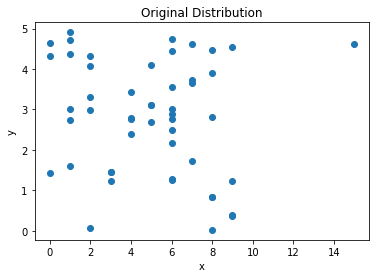

In [ ]:
#Plot of data
plt.scatter(x,y)
plt.title("Original Distribution")
plt.xlabel('x')
plt.ylabel('y')

# plt.xlim((0,500))
plt.savefig('original3.png')
plt.show()



In [ ]:
#Perform min-max normalization
max_x=max(x)
min_x=min(x)
min_y=min(y)
max_y=max(y)

# Applying min-max normalization one by one for each example value of x and y
x_scaled=[(a-min_x)/(max_x-min_x) for a in x]
y_scaled=[(a-min_y)/(max_y-min_y) for a in y]

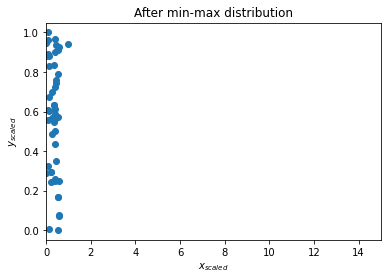

In [ ]:
#Plot of min-max normalized data
plt.scatter(x_scaled,y_scaled)
plt.title("After min-max distribution")
plt.xlabel('$x_{scaled}$')
plt.ylabel('$y_{scaled}$')
plt.xlim((0,15))
plt.savefig('afternormalized3.jpg')
plt.show()


As stated, the data are transformed to scale 0 to 1. Moreover, the above plot also shows how the normalized data are affected by the presence of outlier i.e, most of the datasets are shifted below $x_{scaled}=0.4$.


**References**

1. [Standarization VS Normalisation, Author: Zaid Alissa Almaliki](https://medium.com/@dataakkadian/standardization-vs-normalization-da7a3a308c64)


# Takeaways
The main takeaways of min-max normalisation are:
- The values of Min-max normalisation are scaled between 0 and 1.
- Min-max normalisation is sensitive to outliers.
- Standardization normalisation performs a non-linear transformation.
- Standardization normalisation is less sensitive to outliers.
